In [9]:
import pandas as pd
import matplotlib.pyplot as plt
csv_path = "base_pronta.csv"
df = pd.read_csv(csv_path)
df.head()

,id_aluno,nome,idade,serie,sexo,nota_matematica,nota_portugues,frequencia,media_notas,aprovado
0,1,Pedro Lucas Vieira,11,6º Ano,M,"4,1","3,8","63,7","4,8",Reprovado
1,2,Emanuelly Moreira,10,4º Ano,F,"8,4","7,8","64,6","7,6",Aprovado
2,3,Murilo Nogueira,13,9º Ano,M,"8,1","6,5","68,4","7,1",Aprovado
3,4,Helena Oliveira,14,9º Ano,F,"3,7","3,4","65,4","4,5",Reprovado
4,5,Alice Ribeiro,15,9º Ano,F,"2,7","8,7","89,8","6,8",Reprovado


aprovado
Reprovado    82
Aprovado     18
Name: count, dtype: int64


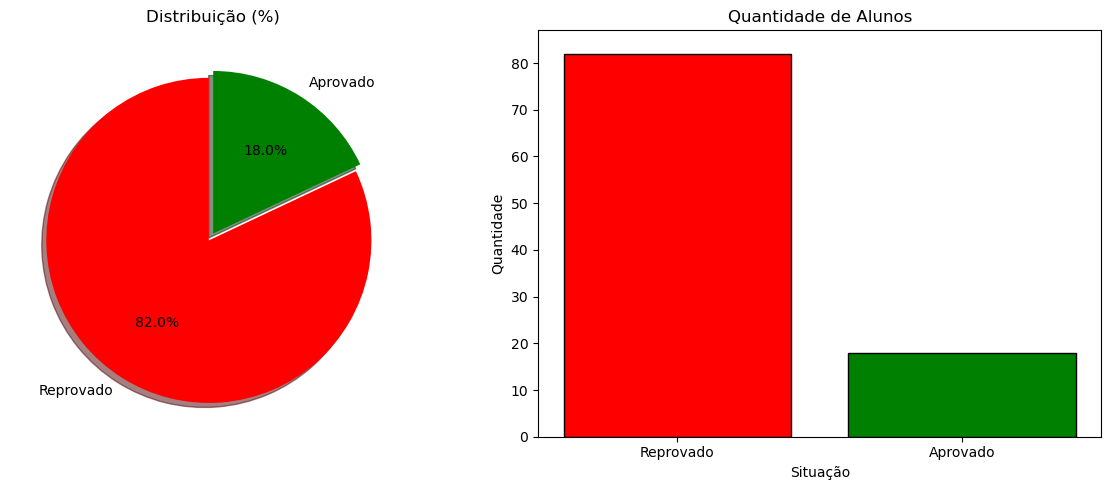

In [10]:

# Dados
contagem = df['aprovado'].value_counts() #aq ele conta os aprovados e conta quantos Aprovados ou reprovados tem, separando a quantidade de cada um
cores = ['red', 'green']
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
print(contagem) # verificação dos dados
# Gráfico de pizza
axs[0].pie(contagem, 
           labels=contagem.index, 
           autopct='%1.1f%%', 
           startangle=90, 
           colors=cores, 
           explode=(0.05, 0),
           shadow=True)
axs[0].set_title('Distribuição (%)')

# Gráfico de barras
axs[1].bar(contagem.index, contagem.values, color=cores, edgecolor='black')
axs[1].set_title('Quantidade de Alunos')
axs[1].set_xlabel('Situação')
axs[1].set_ylabel('Quantidade')
axs[1].set_ylim(0, contagem.max() + 5)

plt.tight_layout()
plt.show()

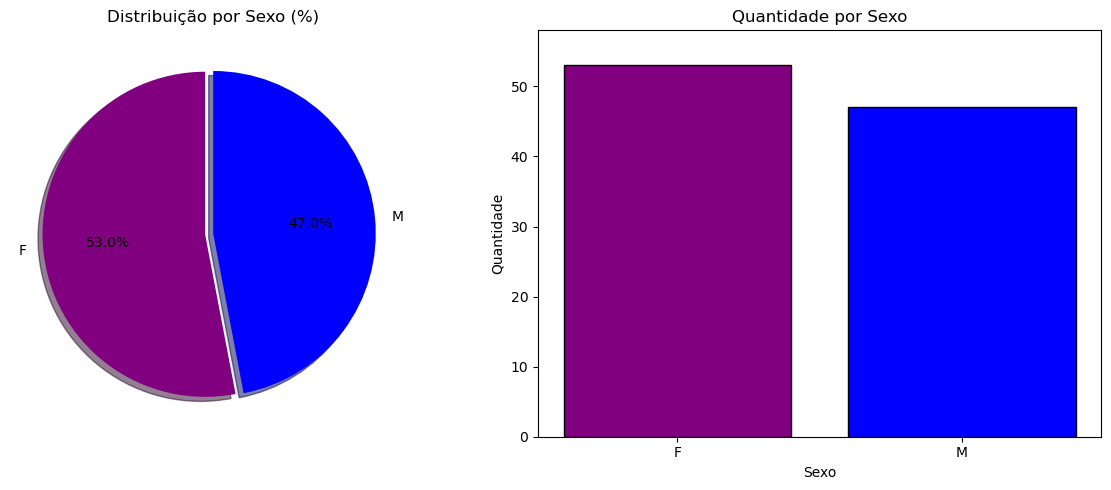

In [11]:
# Contagem de sexo
contagem_sexo = df['sexo'].value_counts() # Pego as quantidades de M e F
cores_sexo = ['purple', 'blue']  

# Criar figura com 2 gráficos lado a lado
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de pizza
axs[0].pie(contagem_sexo, 
           labels=contagem_sexo.index, 
           autopct='%1.1f%%', 
           startangle=90, 
           colors=cores_sexo,
           explode=(0.05, 0),
           shadow=True)
axs[0].set_title('Distribuição por Sexo (%)')

# Gráfico de barras
axs[1].bar(contagem_sexo.index, contagem_sexo.values, color=cores_sexo, edgecolor='black')
axs[1].set_title('Quantidade por Sexo')
axs[1].set_xlabel('Sexo')
axs[1].set_ylabel('Quantidade')
axs[1].set_ylim(0, contagem_sexo.max() + 5)

plt.tight_layout()
plt.show()


In [14]:
df.head()

,id_aluno,nome,idade,serie,sexo,nota_matematica,nota_portugues,frequencia,media_notas,aprovado
0,1,Pedro Lucas Vieira,11,6º Ano,M,"4,1","3,8","63,7",4.8,Reprovado
1,2,Emanuelly Moreira,10,4º Ano,F,"8,4","7,8","64,6",7.6,Aprovado
2,3,Murilo Nogueira,13,9º Ano,M,"8,1","6,5","68,4",7.1,Aprovado
3,4,Helena Oliveira,14,9º Ano,F,"3,7","3,4","65,4",4.5,Reprovado
4,5,Alice Ribeiro,15,9º Ano,F,"2,7","8,7","89,8",6.8,Reprovado


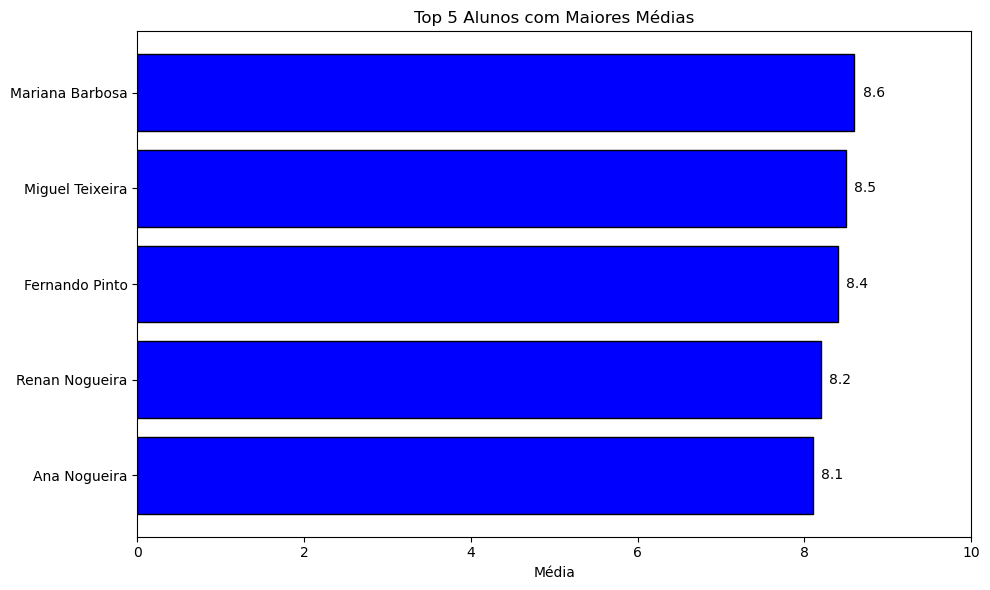

In [16]:
# Ordena pelo valor da média em ordem decrescente e pega os 5 primeiro
# rodei esse comando para poder colocar tudo em formato numerico df['media_notas']=df['media_notas'].str.replace(',','.',regex=False)
df['media_notas'] = pd.to_numeric(df['media_notas'], errors='coerce')
top5 = df.sort_values(by='media_notas', ascending=False).head(5)
# Gráfico de barras horizontais
plt.figure(figsize=(10, 6))
plt.barh(top5['nome'], top5['media_notas'], color='blue', edgecolor='black')
plt.xlabel('Média')
plt.title('Top 5 Alunos com Maiores Médias')
plt.gca().invert_yaxis()  # Inverte para mostrar do maior para o menor no topo

# Ajusta o limite do eixo X de 0 a 10
plt.xlim(0, 10)

# Mostra valores no final da barra
for index, value in enumerate(top5['media_notas']):
    plt.text(value + 0.1, index, f'{value:.1f}', va='center')

plt.tight_layout()
plt.show()


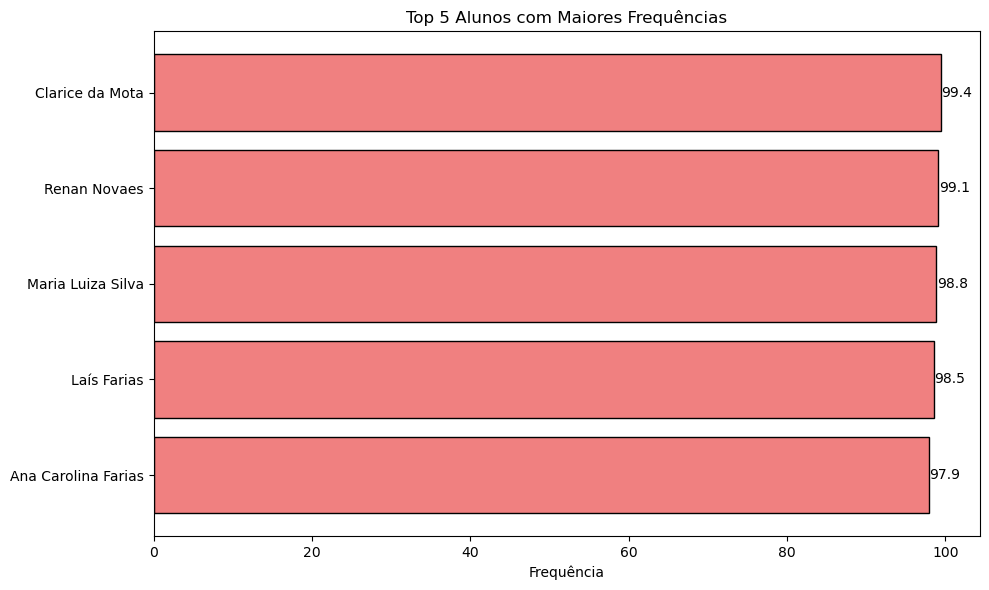

In [17]:
df['frequencia'] = df['frequencia'].str.replace(',', '.').astype(float)


# Ordena pela coluna de frequência em ordem decrescente e pega os 5 primeiros
top5_frequencia = df.sort_values(by='frequencia', ascending=False).head(5)

# Gráfico de barras horizontais
plt.figure(figsize=(10, 6))
plt.barh(top5_frequencia['nome'], top5_frequencia['frequencia'], color='lightcoral', edgecolor='black')
plt.xlabel('Frequência')
plt.title('Top 5 Alunos com Maiores Frequências')
plt.gca().invert_yaxis()  # Inverte para mostrar do maior para o menor no topo

# Mostra valores no final da barra
for index, value in enumerate(top5_frequencia['frequencia']):
    plt.text(value + 0.1, index, f'{value}', va='center')

plt.tight_layout()
plt.show()


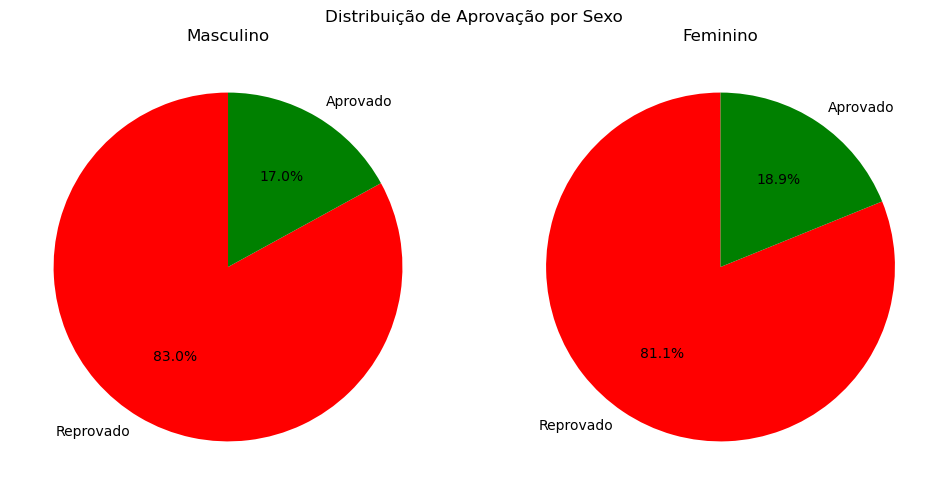

In [18]:
    masc = df[df['sexo'] == 'M']['aprovado'].value_counts()
    fem = df[df['sexo'] == 'F']['aprovado'].value_counts()

    # Criando subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Gráfico dos meninos
    axes[0].pie(masc, labels=masc.index, autopct='%1.1f%%', colors=['red', 'green'], startangle=90)
    axes[0].set_title('Masculino')

    # Gráfico das meninas
    axes[1].pie(fem, labels=fem.index, autopct='%1.1f%%', colors=['red', 'green'], startangle=90)
    axes[1].set_title('Feminino')

    plt.suptitle('Distribuição de Aprovação por Sexo')
    plt.tight_layout()
    plt.show()
